# Chapter 136 — Cross Product

> **Prerequisites:** ch131 (dot product), ch135 (orthogonality), ch121 (vectors)  
> **You will learn:**
> - What the cross product is and when it is defined
> - How to compute it and what its direction and magnitude mean
> - Why the cross product measures oriented area
> - Applications in 3D graphics, physics, and computational geometry
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The **cross product** takes two 3D vectors and returns a third vector that is perpendicular to both:

$$\mathbf{a}\times\mathbf{b} = \begin{vmatrix}\mathbf{i} & \mathbf{j} & \mathbf{k} \\ a_1 & a_2 & a_3 \\ b_1 & b_2 & b_3\end{vmatrix} = (a_2b_3 - a_3b_2,\; a_3b_1 - a_1b_3,\; a_1b_2 - a_2b_1)$$

The cross product is defined only in **3D** (and in 7D, a generalization that is rarely needed). In 2D, there is no vector orthogonal to two given vectors — you can compute a scalar "2D cross product" (the $z$-component only), but it is not a full vector.

**Common misconceptions:**
- The cross product is not commutative: $\mathbf{a}\times\mathbf{b} = -(\mathbf{b}\times\mathbf{a})$.
- The cross product of parallel vectors is the zero vector (they span no area).
- The cross product does not generalize to $n > 3$ dimensions in the same way the dot product does.

## 2. Intuition & Mental Models

**Geometric:** Place your right hand so your fingers curl from $\mathbf{a}$ toward $\mathbf{b}$. Your thumb points in the direction of $\mathbf{a}\times\mathbf{b}$. This is the **right-hand rule** — it encodes orientation.

**Area:** The magnitude $\|\mathbf{a}\times\mathbf{b}\|$ equals the area of the parallelogram spanned by $\mathbf{a}$ and $\mathbf{b}$:
$$\|\mathbf{a}\times\mathbf{b}\| = \|\mathbf{a}\|\|\mathbf{b}\|\sin\theta$$

When $\mathbf{a}$ and $\mathbf{b}$ are parallel ($\theta = 0$), the area is zero and so is the cross product.

**Computational (3D graphics):** Surface normals in 3D meshes are computed via cross products. Two edges of a triangle give two vectors; their cross product gives the direction the surface faces. Every lighting calculation in graphics depends on this.

**Contrast with dot product:** The dot product measures *parallel alignment* (cosine of angle). The cross product measures *perpendicular extent* (sine of angle). Together they decompose the full geometric relationship between two vectors.

Recall from ch135: the cross product vector is orthogonal to both inputs — its dot product with either $\mathbf{a}$ or $\mathbf{b}$ is zero.

## 3. Visualization

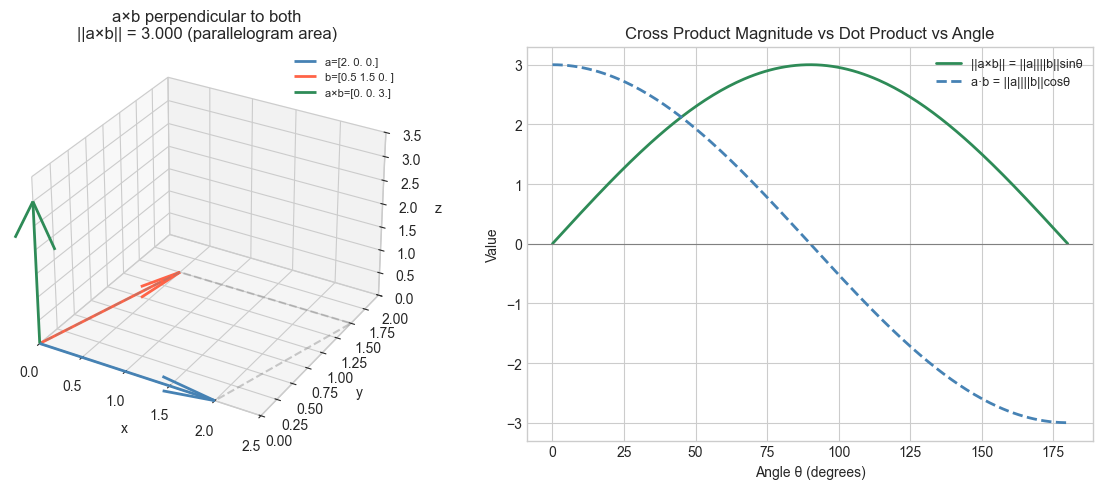

In [1]:
# --- Visualization: Cross product as perpendicular vector ---

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8-whitegrid')

a = np.array([2.0, 0.0, 0.0])
b = np.array([0.5, 1.5, 0.0])
c = np.cross(a, b)

fig = plt.figure(figsize=(12, 5))

# 3D view
ax3d = fig.add_subplot(121, projection='3d')
ORIGIN = np.zeros(3)
ax3d.quiver(*ORIGIN, *a, color='steelblue', linewidth=2, label=f'a={a}')
ax3d.quiver(*ORIGIN, *b, color='tomato',    linewidth=2, label=f'b={b}')
ax3d.quiver(*ORIGIN, *c, color='seagreen',  linewidth=2, label=f'a×b={np.round(c,2)}')

# Draw parallelogram
corners = np.array([ORIGIN, a, a+b, b, ORIGIN])
ax3d.plot(corners[:,0], corners[:,1], corners[:,2], 'gray', alpha=0.4, linestyle='--')

ax3d.set_xlim(0, 2.5); ax3d.set_ylim(0, 2); ax3d.set_zlim(0, 3.5)
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('z')
ax3d.set_title(f'a×b perpendicular to both\n||a×b|| = {np.linalg.norm(c):.3f} (parallelogram area)')
ax3d.legend(fontsize=8)

# Angle sweep: |a×b| = ||a|| ||b|| sin(θ)
ax2 = fig.add_subplot(122)
thetas = np.linspace(0, np.pi, 200)
norm_a, norm_b = 2.0, 1.5
cross_mags = norm_a * norm_b * np.sin(thetas)
dot_prods   = norm_a * norm_b * np.cos(thetas)

ax2.plot(np.degrees(thetas), cross_mags, 'seagreen', linewidth=2, label='||a×b|| = ||a||||b||sinθ')
ax2.plot(np.degrees(thetas), dot_prods,  'steelblue', linewidth=2, linestyle='--', label='a·b = ||a||||b||cosθ')
ax2.axhline(0, color='gray', linewidth=0.8)
ax2.set_xlabel('Angle θ (degrees)')
ax2.set_ylabel('Value')
ax2.set_title('Cross Product Magnitude vs Dot Product vs Angle')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

**Component formula:**
$$\mathbf{a}\times\mathbf{b} = \begin{pmatrix} a_2b_3 - a_3b_2 \\ a_3b_1 - a_1b_3 \\ a_1b_2 - a_2b_1 \end{pmatrix}$$

**Properties:**
- **Anti-commutativity:** $\mathbf{a}\times\mathbf{b} = -(\mathbf{b}\times\mathbf{a})$
- **Bilinearity:** $(c\mathbf{a})\times\mathbf{b} = c(\mathbf{a}\times\mathbf{b})$; $\mathbf{a}\times(\mathbf{b}+\mathbf{c}) = \mathbf{a}\times\mathbf{b} + \mathbf{a}\times\mathbf{c}$
- **Zero for parallels:** $\mathbf{a}\times\mathbf{a} = \mathbf{0}$
- **Orthogonality:** $\mathbf{a}\cdot(\mathbf{a}\times\mathbf{b}) = 0$ and $\mathbf{b}\cdot(\mathbf{a}\times\mathbf{b}) = 0$

**Magnitude:**
$$\|\mathbf{a}\times\mathbf{b}\| = \|\mathbf{a}\|\|\mathbf{b}\|\sin\theta$$

This is the area of the parallelogram spanned by $\mathbf{a}$ and $\mathbf{b}$.

**Triple product (scalar):** The signed volume of the parallelepiped spanned by three vectors:
$$V = \mathbf{a}\cdot(\mathbf{b}\times\mathbf{c})$$

If $V = 0$, the three vectors are coplanar (linearly dependent). *(This connects to ch158 — Determinants, which generalizes signed volume.)*

## 5. Python Implementation

In [2]:
# --- Implementation: cross product from scratch ---

def cross_product(a, b):
    """
    3D cross product.

    Args:
        a, b: array-like, shape (3,)

    Returns:
        array, shape (3,): vector perpendicular to both a and b

    Raises:
        ValueError: if inputs are not 3D
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    if a.shape != (3,) or b.shape != (3,):
        raise ValueError(f"Cross product requires 3D vectors, got {a.shape} and {b.shape}")
    return np.array([
        a[1]*b[2] - a[2]*b[1],
        a[2]*b[0] - a[0]*b[2],
        a[0]*b[1] - a[1]*b[0],
    ])


def parallelogram_area(a, b):
    """Area of parallelogram spanned by a and b."""
    return np.linalg.norm(cross_product(a, b))


def triangle_area(p1, p2, p3):
    """Area of triangle with vertices p1, p2, p3 in 3D."""
    v1 = np.asarray(p2) - np.asarray(p1)
    v2 = np.asarray(p3) - np.asarray(p1)
    return 0.5 * parallelogram_area(v1, v2)


def triple_product(a, b, c):
    """Scalar triple product = a · (b × c) = signed volume."""
    return np.dot(np.asarray(a), cross_product(b, c))


def surface_normal(p1, p2, p3):
    """Unit normal vector of a triangle (for 3D graphics)."""
    v1 = np.asarray(p2, float) - np.asarray(p1, float)
    v2 = np.asarray(p3, float) - np.asarray(p1, float)
    n = cross_product(v1, v2)
    return n / np.linalg.norm(n)


# Tests
a = np.array([1.0, 0.0, 0.0])
b = np.array([0.0, 1.0, 0.0])
c = cross_product(a, b)
print(f"e1 × e2 = {c}  (expect [0, 0, 1])")
print(f"e2 × e1 = {cross_product(b, a)}  (expect [0, 0, -1])  — anti-commutative")

print(f"\nOrthogonality check: a·(a×b) = {np.dot(a, c):.2e}")
print(f"Orthogonality check: b·(a×b) = {np.dot(b, c):.2e}")

# Triangle area
p1 = np.array([0.0, 0.0, 0.0])
p2 = np.array([1.0, 0.0, 0.0])
p3 = np.array([0.0, 1.0, 0.0])
print(f"\nTriangle area: {triangle_area(p1, p2, p3):.4f}  (expect 0.5)")

# Validate against numpy
a_rand = np.random.randn(3)
b_rand = np.random.randn(3)
assert np.allclose(cross_product(a_rand, b_rand), np.cross(a_rand, b_rand))
print("Validation against np.cross: PASSED")

e1 × e2 = [0. 0. 1.]  (expect [0, 0, 1])
e2 × e1 = [ 0.  0. -1.]  (expect [0, 0, -1])  — anti-commutative

Orthogonality check: a·(a×b) = 0.00e+00
Orthogonality check: b·(a×b) = 0.00e+00

Triangle area: 0.5000  (expect 0.5)
Validation against np.cross: PASSED


## 6. Experiments

In [3]:
# --- Experiment 1: Anti-commutativity and its geometric meaning ---
# Hypothesis: a×b and b×a have the same magnitude but opposite directions.
# Swapping the input order flips the surface normal.

a = np.array([1.0, 2.0, 0.5])
b = np.array([0.5, 1.0, 2.0])

axb = cross_product(a, b)
bxa = cross_product(b, a)

print(f"a × b = {np.round(axb, 3)}")
print(f"b × a = {np.round(bxa, 3)}")
print(f"Sum:   {np.round(axb + bxa, 10)}  (should be zero)")
print(f"||a×b|| = ||b×a|| = {np.linalg.norm(axb):.4f}")

a × b = [ 3.5  -1.75  0.  ]
b × a = [-3.5   1.75  0.  ]
Sum:   [0. 0. 0.]  (should be zero)
||a×b|| = ||b×a|| = 3.9131


In [4]:
# --- Experiment 2: Area computation via cross product ---
# Hypothesis: splitting a polygon into triangles and summing areas
# gives the correct total area.
# Try changing: RADIUS and N_SIDES

N_SIDES = 6    # <-- modify this
RADIUS  = 2.0  # <-- modify this

# Regular polygon vertices in XY plane (z = 0)
angles = np.linspace(0, 2*np.pi, N_SIDES, endpoint=False)
vertices = np.column_stack([
    RADIUS * np.cos(angles),
    RADIUS * np.sin(angles),
    np.zeros(N_SIDES)
])

center = np.zeros(3)
total_area = sum(
    triangle_area(center, vertices[i], vertices[(i+1) % N_SIDES])
    for i in range(N_SIDES)
)

# Analytical area of regular polygon
true_area = 0.5 * N_SIDES * RADIUS**2 * np.sin(2*np.pi/N_SIDES)

print(f"N_SIDES = {N_SIDES}, RADIUS = {RADIUS}")
print(f"Cross-product area: {total_area:.6f}")
print(f"Analytical area:    {true_area:.6f}")
print(f"Error: {abs(total_area - true_area):.2e}")
print(f"\n(As N_SIDES → ∞, the polygon approaches a circle with area π*R² = {np.pi*RADIUS**2:.4f})")

N_SIDES = 6, RADIUS = 2.0
Cross-product area: 10.392305
Analytical area:    10.392305
Error: 0.00e+00

(As N_SIDES → ∞, the polygon approaches a circle with area π*R² = 12.5664)


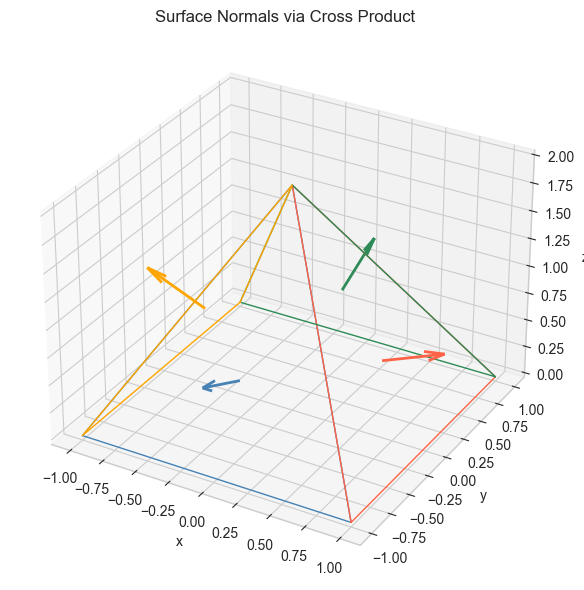

In [5]:
# --- Experiment 3: Surface normals in a simple 3D mesh ---
# Compute and display surface normals for a set of triangles.
# Try changing: the vertex positions.

# A simple "tent" shape: 4 triangles
apex   = np.array([0.0, 0.0, 2.0])  # <-- modify this
p1 = np.array([-1.0, -1.0, 0.0])
p2 = np.array([ 1.0, -1.0, 0.0])
p3 = np.array([ 1.0,  1.0, 0.0])
p4 = np.array([-1.0,  1.0, 0.0])

triangles = [(p1, p2, apex), (p2, p3, apex), (p3, p4, apex), (p4, p1, apex)]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

COLORS = ['steelblue', 'tomato', 'seagreen', 'orange']
for (t1, t2, t3), color in zip(triangles, COLORS):
    n = surface_normal(t1, t2, t3)
    centroid = (t1 + t2 + t3) / 3
    # Draw triangle edges
    tri = np.array([t1, t2, t3, t1])
    ax.plot(tri[:,0], tri[:,1], tri[:,2], color=color, linewidth=1)
    # Draw normal at centroid
    ax.quiver(*centroid, *n*0.5, color=color, linewidth=2)

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title('Surface Normals via Cross Product')
plt.tight_layout()
plt.show()

## 7. Exercises

**Easy 1.** Compute $[1, 2, 3] \times [4, 5, 6]$ by hand using the formula, then verify with `np.cross`. *(Expected: $[-3, 6, -3]$)*

**Easy 2.** What is $\mathbf{v}\times\mathbf{v}$ for any vector $\mathbf{v}$? Why? *(Expected: the zero vector — prove using the formula)*

**Medium 1.** Given three points $P_1 = [0,0,0]$, $P_2 = [3,0,0]$, $P_3 = [0,4,0]$, find the equation of the plane through them. *(Hint: the surface normal gives the plane's coefficients $ax + by + cz = d$)*

**Medium 2.** Verify the Jacobi identity numerically: $\mathbf{a}\times(\mathbf{b}\times\mathbf{c}) + \mathbf{b}\times(\mathbf{c}\times\mathbf{a}) + \mathbf{c}\times(\mathbf{a}\times\mathbf{b}) = \mathbf{0}$. Test on 10 random triples.

**Hard.** The **vector triple product** satisfies $\mathbf{a}\times(\mathbf{b}\times\mathbf{c}) = \mathbf{b}(\mathbf{a}\cdot\mathbf{c}) - \mathbf{c}(\mathbf{a}\cdot\mathbf{b})$ (the BAC-CAB rule). Prove this algebraically by expanding both sides in components. Then verify numerically.

## 8. Mini Project — 3D Mesh Normal Smoothing

In [ ]:
# --- Mini Project: Surface Normal Computation for a Sphere Mesh ---
# Problem: Approximate a sphere with triangulated faces.
#          Compute per-face surface normals using the cross product.
# Dataset: Parametric sphere mesh generated here.
# Task: Complete compute_face_normals and visualize with quiver plot.

def generate_sphere_mesh(n_lat=8, n_lon=8, radius=1.0):
    """
    Generate triangle faces of a sphere.

    Returns:
        faces: list of (p1, p2, p3) triangles, each vertex is shape (3,)
    """
    lats = np.linspace(0, np.pi, n_lat + 1)
    lons = np.linspace(0, 2*np.pi, n_lon + 1)

    def to_xyz(lat, lon):
        return radius * np.array([np.sin(lat)*np.cos(lon),
                                   np.sin(lat)*np.sin(lon),
                                   np.cos(lat)])

    faces = []
    for i in range(n_lat):
        for j in range(n_lon):
            p00 = to_xyz(lats[i],   lons[j])
            p10 = to_xyz(lats[i+1], lons[j])
            p01 = to_xyz(lats[i],   lons[j+1])
            p11 = to_xyz(lats[i+1], lons[j+1])
            faces.append((p00, p10, p11))
            faces.append((p00, p11, p01))
    return faces


def compute_face_normals(faces):
    """
    Compute unit normal for each triangular face.

    Args:
        faces: list of (p1, p2, p3) triangles

    Returns:
        centroids: array (n_faces, 3)
        normals:   array (n_faces, 3), unit normals
    """
    centroids = []
    normals   = []
    for p1, p2, p3 in faces:
        # TODO: compute centroid
        centroid = None  # replace
        # TODO: compute unit normal via cross product
        normal = None    # replace
        centroids.append(centroid)
        normals.append(normal)
    return np.array(centroids), np.array(normals)


# --- Test (uncomment after implementing) ---
# faces = generate_sphere_mesh(n_lat=6, n_lon=6)
# centroids, normals = compute_face_normals(faces)
#
# fig = plt.figure(figsize=(8, 8))
# ax = fig.add_subplot(111, projection='3d')
# ax.quiver(centroids[:,0], centroids[:,1], centroids[:,2],
#            normals[:,0],   normals[:,1],   normals[:,2],
#            length=0.15, color='tomato', alpha=0.7)
# ax.set_title('Surface Normals on Sphere Mesh')
# ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
# plt.tight_layout()
# plt.show()
#
# # Verification: for a unit sphere, the normal at any surface point
# # should equal the position vector itself.
# dot_check = np.sum(centroids * normals, axis=1)
# print(f"Normal · centroid (should be ~1.0): min={dot_check.min():.4f}, max={dot_check.max():.4f}")

## 9. Chapter Summary & Connections

- The cross product $\mathbf{a}\times\mathbf{b}$ is a vector perpendicular to both $\mathbf{a}$ and $\mathbf{b}$, defined only in 3D.
- Its magnitude $= \|\mathbf{a}\|\|\mathbf{b}\|\sin\theta$ gives the area of the parallelogram they span.
- It is anti-commutative: $\mathbf{a}\times\mathbf{b} = -(\mathbf{b}\times\mathbf{a})$ — order matters and encodes orientation.
- The scalar triple product $\mathbf{a}\cdot(\mathbf{b}\times\mathbf{c})$ gives signed volume and detects coplanarity.

**Forward connections:**
- This reappears in **ch158 — Determinants**, where the 3×3 determinant equals the scalar triple product — generalizing signed volume to $n$ dimensions.
- This reappears in **ch149 — Project: Particle Simulation**, where cross products compute torque and angular momentum.
- This is the foundation of surface rendering in **ch115 — Computer Graphics Basics**.

**Backward connection:**
- This builds on **ch135 — Orthogonality**: the result is perpendicular to both inputs by construction, verified by $\mathbf{a}\cdot(\mathbf{a}\times\mathbf{b}) = 0$.

**Going deeper:** The cross product is a special case of the **exterior product** (wedge product) in differential geometry. The exterior product generalizes to any dimension and underlies differential forms, Stokes' theorem, and manifold theory.